In [1]:
import numpy as np
import pandas as pd
import bayesflow as bf
import keras
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import benchmark.examples.gaussian.analysis.mmd_err as MMD

INFO:bayesflow:Using backend 'jax'


In [ ]:
# settings of this notebook
# num_dims=3
# num_obs=20
# likelihood_std=1
# student_df=5
# 1.mu=0,normal  2. mu=5, noraml 3. mu=0,student_t,df=5

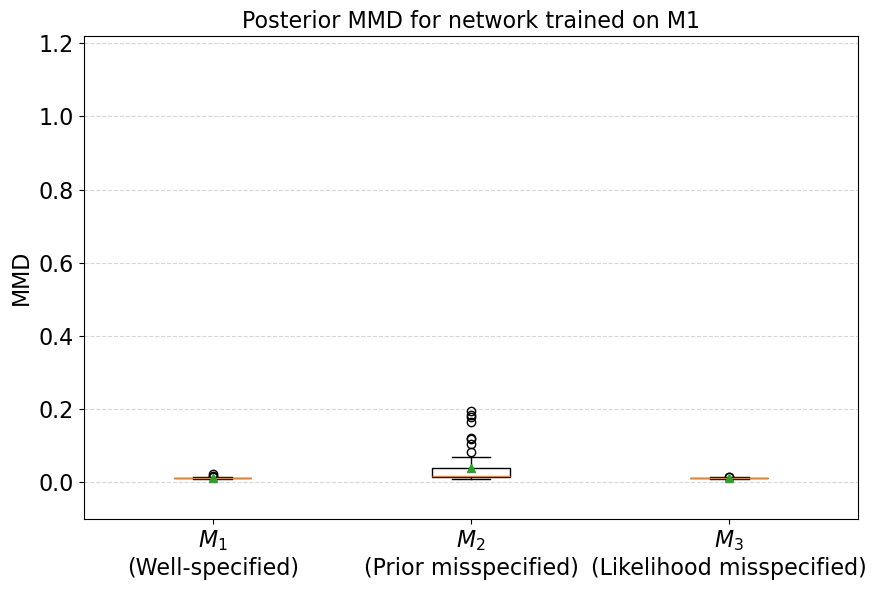

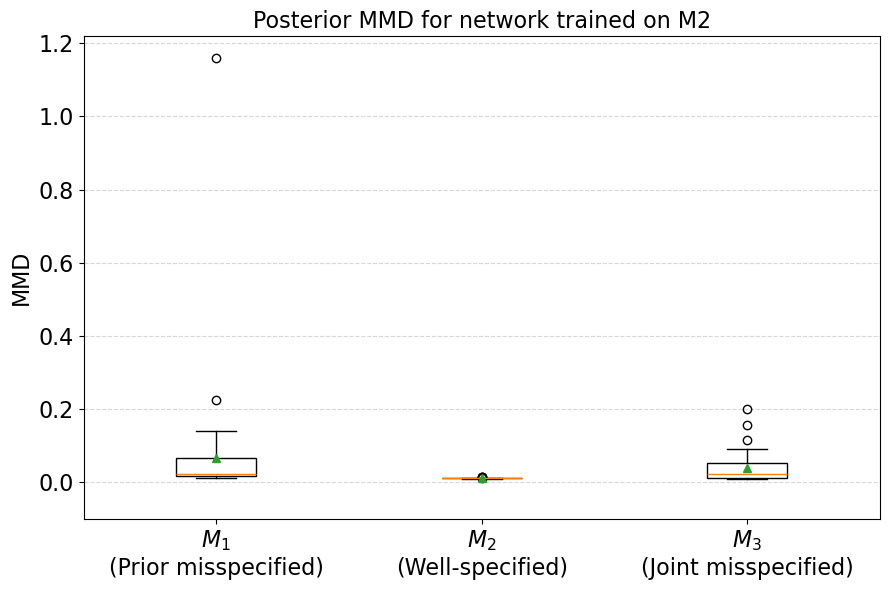

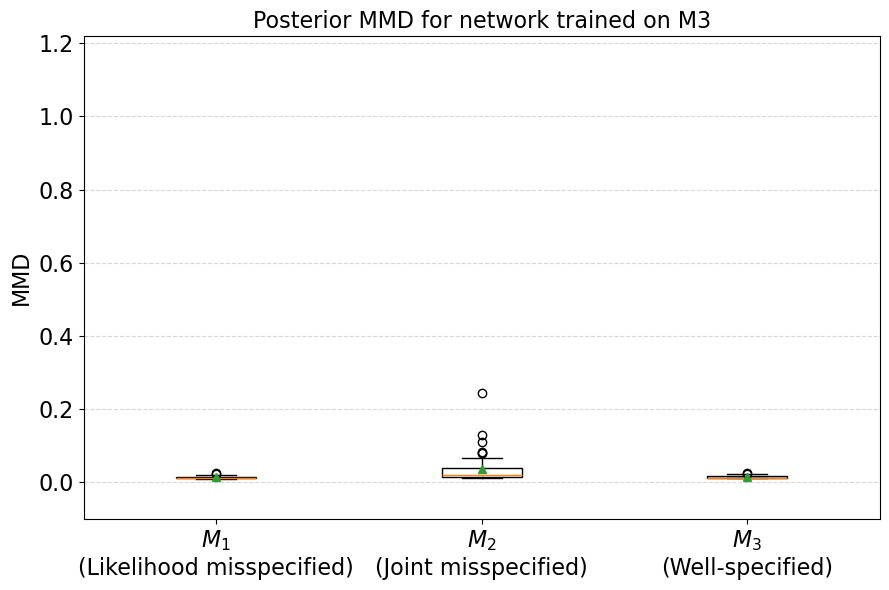

In [4]:
models = ["m1", "m2", "m3"]
posterior_results = {m: MMD.run_posterior_mmd_analysis(assumed_model=m) for m in models}

posterior_ymax = max(result["long_df"]["mmd"].max() for result in posterior_results.values())
posterior_ylim = (-0.1, posterior_ymax * 1.05)

for m in models:
    MMD.build_metric_boxplot(
        df=posterior_results[m]["long_df"],
        assumed_model=m,
        value_col="mmd",
        ylabel="MMD",
        title=f"Posterior MMD for network trained on {m.upper()}",
        y_limits=posterior_ylim,
    )


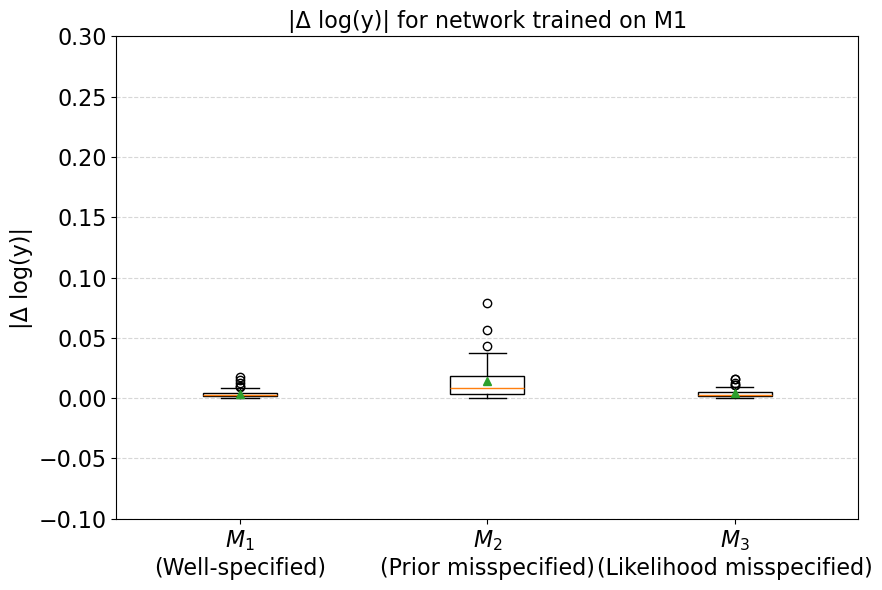

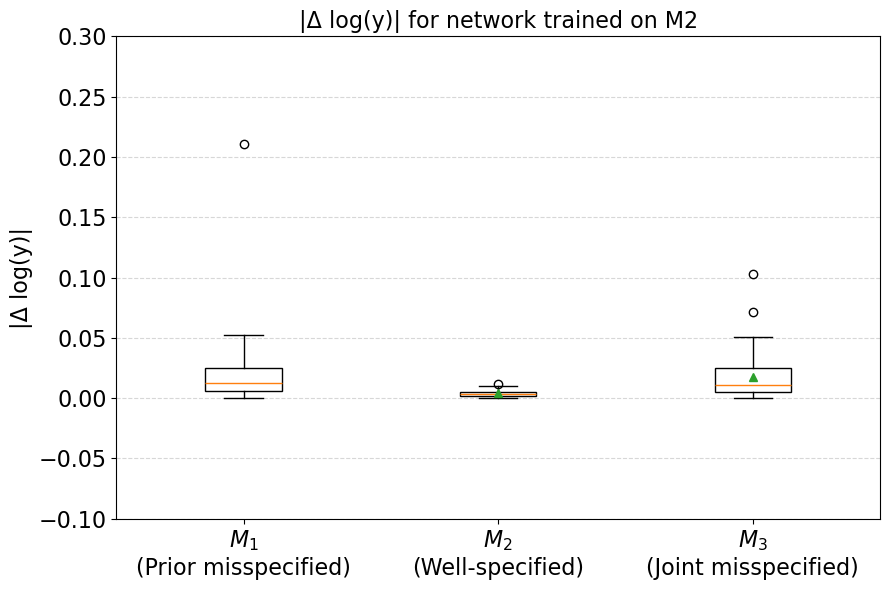

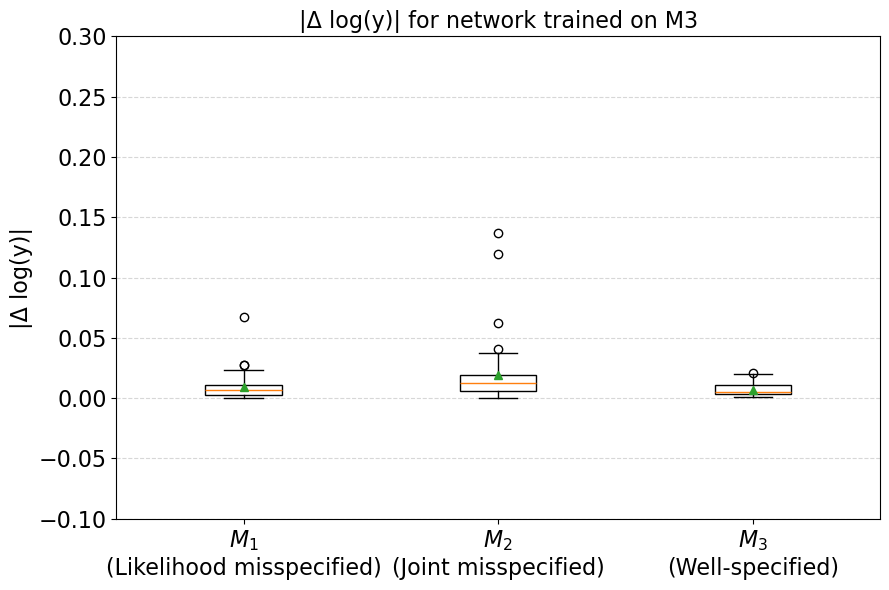

In [ ]:
# models = ["m1", "m2", "m3"]
# logml_results = {m: MMD.run_logml_abs_error_analysis(assumed_model=m) for m in models}

# logml_ymax = max(result["long_df"]["abs_error"].max() for result in logml_results.values())
# logml_ylim = (-10, logml_ymax * 1.05)

# for m in models:
#     MMD.build_metric_boxplot(
#         df=logml_results[m]["long_df"],
#         assumed_model=m,
#         value_col="abs_error",
#         ylabel="|Δ log(y)|",
#         title=f"|Δ log(y)| for network trained on {m.upper()}",
#         y_limits=(-0.1,0.3),
#     )


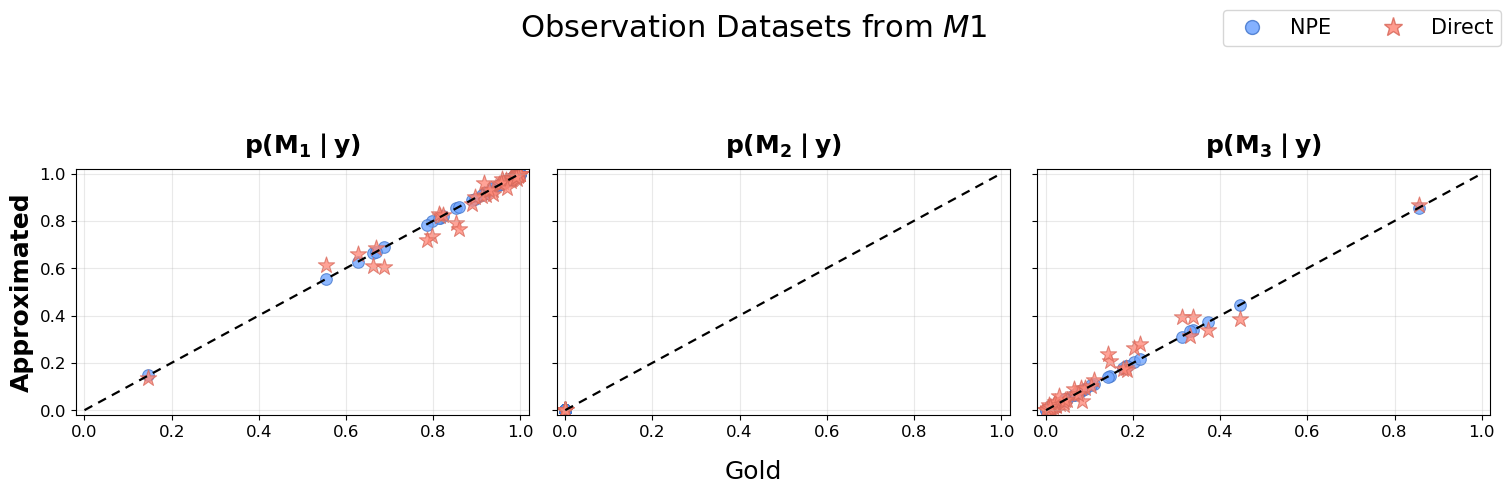

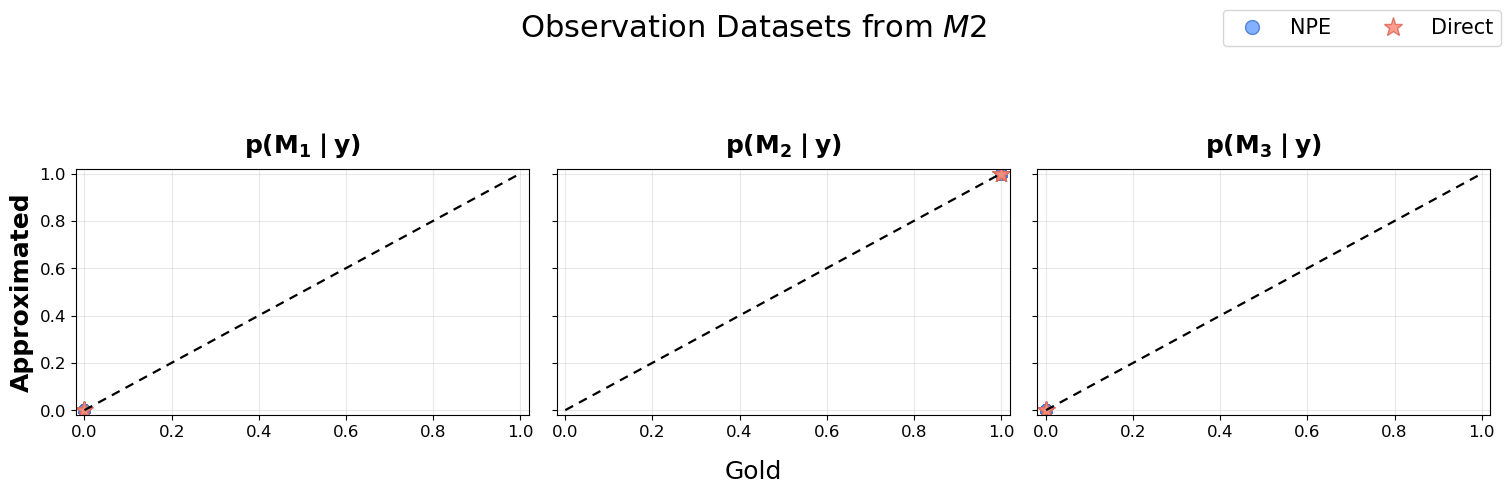

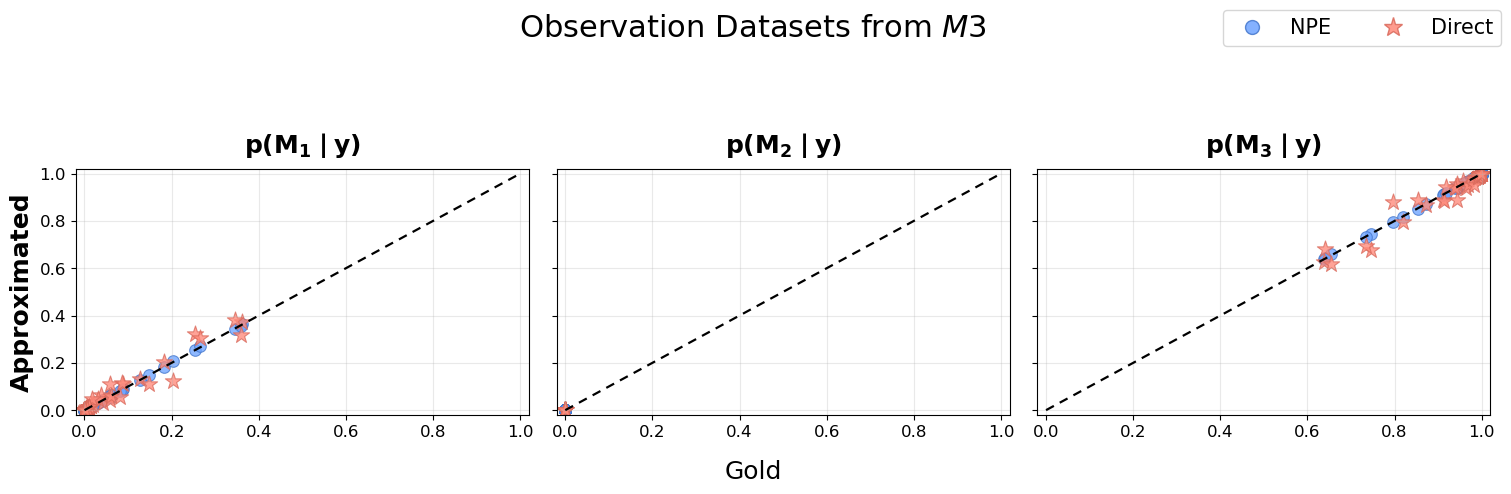

In [22]:
DATASETS_DIR = Path(
    "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets"
)

def normalize_prob(p, eps=1e-12):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0)
    return p / p.sum()

panel_titles = [
    r"$\mathbf{p(M_1\mid y)}$",
    r"$\mathbf{p(M_2\mid y)}$",
    r"$\mathbf{p(M_3\mid y)}$",
]

for source_model in ["m1", "m2", "m3"]:
    dataset_path = DATASETS_DIR / f"{source_model}.pkl"

    with dataset_path.open("rb") as f:
        datasets = pickle.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), sharex=True, sharey=True)

    for j, ax in enumerate(axes):
        gold = np.array([normalize_prob(item["p_gold"])[j] for item in datasets])
        npe = np.array([normalize_prob(item["p_npe"])[j] for item in datasets])
        direct = np.array([normalize_prob(item["p_direct"])[j] for item in datasets])

        ax.scatter(
            gold, npe,
            s=70, alpha=0.78,
            color="#6FA4FF", edgecolor="#4477CC", linewidth=0.8,
        )
        ax.scatter(
            gold, direct,
            s=150, alpha=0.78,
            marker="*", color="#FF8A7A", edgecolor="#D96A5C", linewidth=0.8,
        )

        ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1.6, dashes=(4, 3))
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.28)
        ax.set_title(panel_titles[j], fontsize=18, pad=12)
        ax.tick_params(labelsize=12)

    axes[0].set_ylabel("Approximated", fontsize=18, fontweight="bold")
    fig.supxlabel("Gold", fontsize=18, y=0.04)
    fig.suptitle(rf"Observation Datasets from ${source_model.upper()}$", fontsize=22, y=1.02)

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o", linestyle="None", markersize=10,
            markerfacecolor="#6FA4FF", markeredgecolor="#4477CC",
            label="NPE", alpha=0.85
        ),
        Line2D(
            [0], [0],
            marker="*", linestyle="None", markersize=14,
            markerfacecolor="#FF8A7A", markeredgecolor="#D96A5C",
            label="Direct", alpha=0.85
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper right",
        bbox_to_anchor=(0.98, 1.05),
        ncol=2,
        frameon=True,
        fontsize=15,
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.9])
    plt.show()


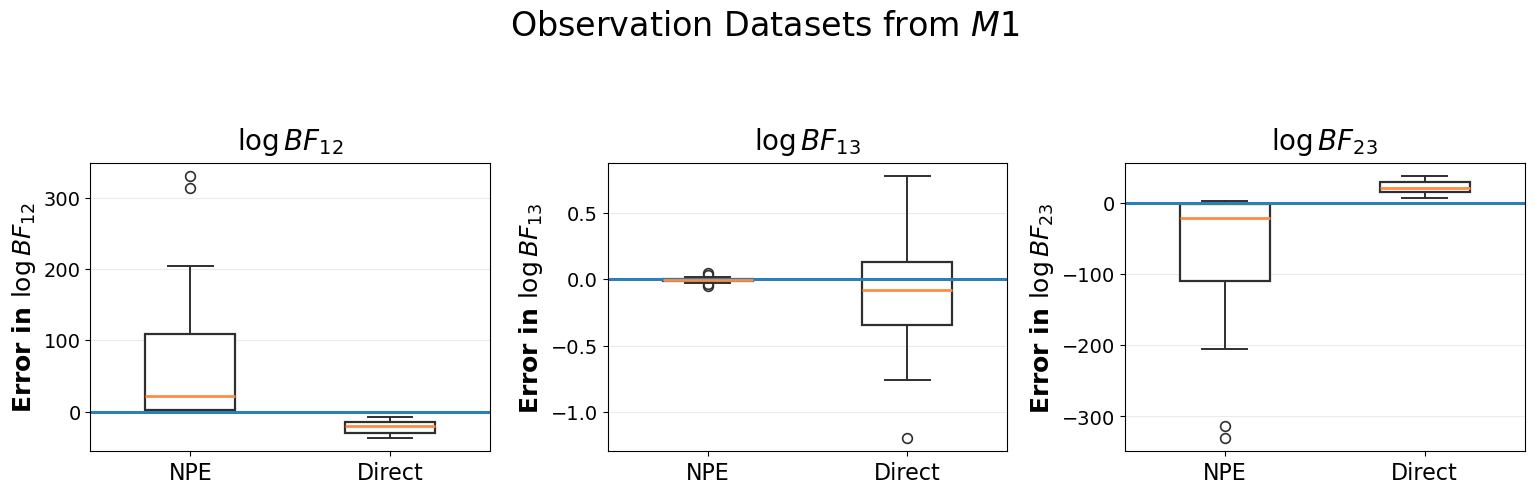

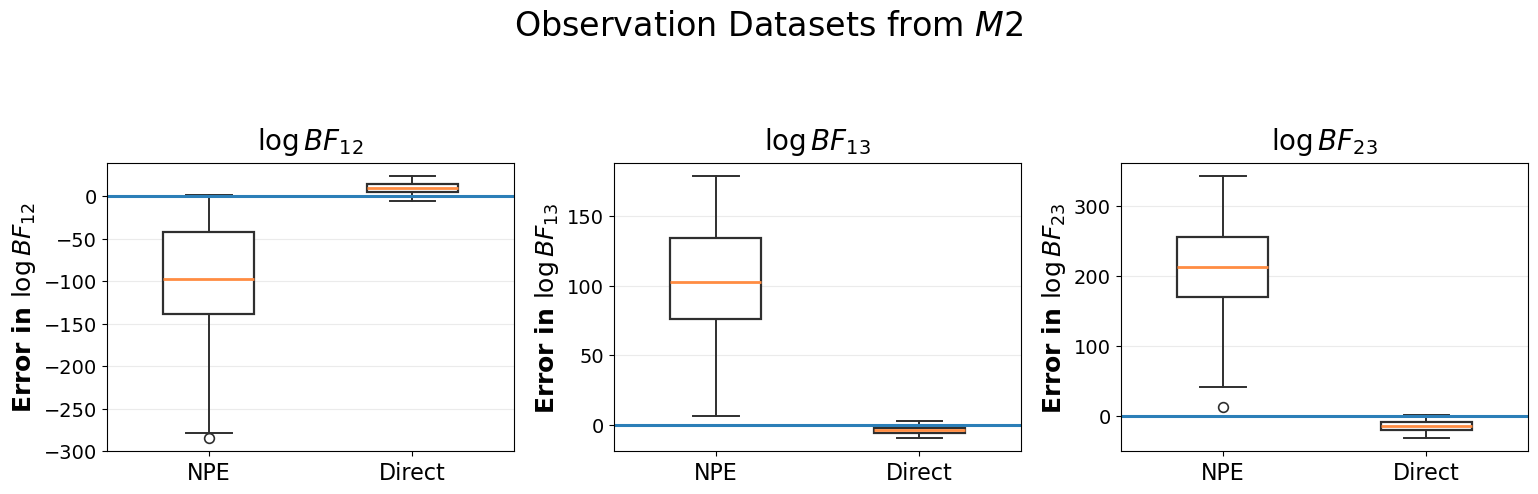

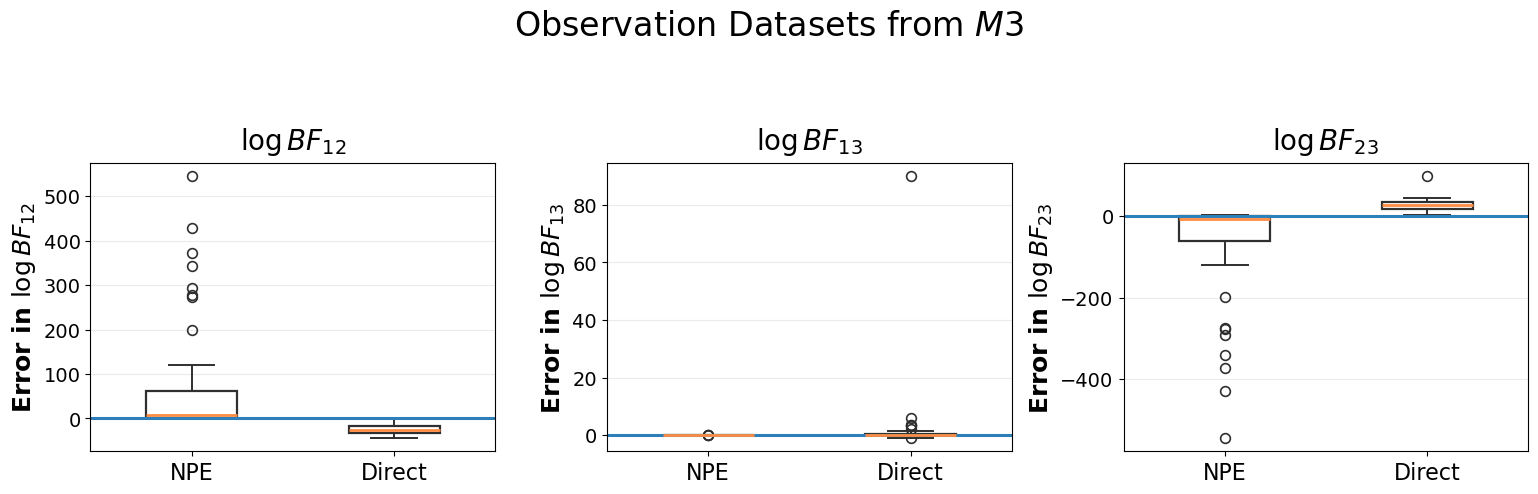

In [17]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "benchmark").exists():
            return candidate
    raise RuntimeError("Could not locate project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
GAUSSIAN_DIR = PROJECT_ROOT / "benchmark" / "examples" / "gaussian"
DATASETS_DIR = GAUSSIAN_DIR / "results" / "datasets"

def load_datasets(source_model: str):
    with (DATASETS_DIR / f"{source_model}.pkl").open("rb") as f:
        return pickle.load(f)
    
pairs = ["12", "13", "23"]
source_models = ["m1", "m2", "m3"]

line_color = "#2C7FB8"
box_edge = "#2F2F2F"
median_color = "#FF8C42"
grid_color = "#C7C7C7"

for source_model in source_models:
    datasets = load_datasets(source_model)

    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), sharex=False)

    for ax, pair in zip(axes, pairs):
        npe_err = [
            float(item[f"logBF_{pair}_npe"]) - float(item[f"logBF_{pair}_gold"])
            for item in datasets
        ]
        direct_err = [
            float(item[f"logBF_{pair}_direct"]) - float(item[f"logBF_{pair}_gold"])
            for item in datasets
        ]

        ax.boxplot(
            [npe_err, direct_err],
            tick_labels=["NPE", "Direct"],
            widths=0.45,
            patch_artist=True,
            boxprops={
                "facecolor": "white",
                "edgecolor": box_edge,
                "linewidth": 1.6,
            },
            medianprops={
                "color": median_color,
                "linewidth": 2.0,
            },
            whiskerprops={
                "color": box_edge,
                "linewidth": 1.4,
            },
            capprops={
                "color": box_edge,
                "linewidth": 1.4,
            },
            flierprops={
                "marker": "o",
                "markerfacecolor": "none",
                "markeredgecolor": box_edge,
                "markersize": 7,
                "markeredgewidth": 1.2,
            },
        )

        ax.axhline(0.0, color=line_color, linewidth=2.2)
        ax.set_title(rf"$\log BF_{{{pair}}}$", fontsize=20, pad=10)
        ax.set_ylabel(rf"Error in $\log BF_{{{pair}}}$", fontsize=18, fontweight="bold")
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(axis="y", color=grid_color, alpha=0.35)

    fig.suptitle(rf"Observation Datasets from ${source_model.upper()}$", fontsize=24, y=1.03)
    fig.tight_layout(rect=[0.01, 0.01, 0.99, 0.92])
    plt.show()




In [21]:
source_models = ["m1", "m2", "m3"]
prob_keys = ["p_gold", "p_npe", "p_direct"]

rows = []
for source_model in source_models:
    datasets = load_datasets(source_model)

    for prob_key in prob_keys:
        arr = np.array([np.asarray(item[prob_key], dtype=float) for item in datasets])
        mean_vec = arr.mean(axis=0)

        rows.append(
            {
                "source_model": source_model,
                "probability": prob_key,
                "mean_M1": mean_vec[0].round(3),
                "mean_M2": mean_vec[1].round(3),
                "mean_M3": mean_vec[2].round(3),
                "sum": mean_vec.sum().round(3),
            }
        )

mean_df = pd.DataFrame(rows)
mean_df


,source_model,probability,mean_M1,mean_M2,mean_M3,sum
0,m1,p_gold,0.899,0.0,0.101,1.0
1,m1,p_npe,0.899,0.0,0.101,1.0
2,m1,p_direct,0.892,0.0,0.108,1.0
3,m2,p_gold,0.000,1.0,0.000,1.0
4,m2,p_npe,0.000,1.0,0.000,1.0
5,m2,p_direct,0.000,1.0,0.000,1.0
6,m3,p_gold,0.060,0.0,0.940,1.0
7,m3,p_npe,0.060,0.0,0.940,1.0
8,m3,p_direct,0.064,0.0,0.936,1.0
